## Import libraries

In [57]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [58]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras import layers
from tabulate import tabulate
from pydantic import BaseModel
from typing import Dict, List
import joblib
import json
import time
import os

MODEL_DIR  = "models"
MODELS_JSON = "models.json"
os.makedirs(MODEL_DIR, exist_ok=True)

def _load_registry() -> dict:
    if os.path.exists(MODELS_JSON):
        with open(MODELS_JSON) as f:
            return json.load(f)
    return {}

def _save_registry(registry: dict):
    with open(MODELS_JSON, "w") as f:
        json.dump(registry, f, indent=2)

In [59]:
# Configure TensorFlow to use GPU > TPU > CPU (whichever is available)

def configure_tf_device():
    # Suppress verbose TF/CUDA logs before device selection
    os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

    # 1. Try TPU
    try:
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        print(f"TPU detected — using TPUStrategy ({strategy.num_replicas_in_sync} cores)")
        return strategy, "TPU"
    except (ValueError, tf.errors.NotFoundError):
        pass

    # 2. Try GPU
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            strategy = tf.distribute.MirroredStrategy()
            print(f"GPU detected — using MirroredStrategy ({len(gpus)} GPU(s): "
                  f"{[g.name for g in gpus]})")
            return strategy, "GPU"
        except RuntimeError as e:
            print(f"GPU found but could not be configured: {e}")

    # 3. Fallback to CPU
    strategy = tf.distribute.get_strategy()   # default (no-op) strategy
    print("No GPU/TPU found — falling back to CPU")
    return strategy, "CPU"

tf_strategy, tf_device = configure_tf_device()


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
GPU detected — using MirroredStrategy (1 GPU(s): ['/physical_device:GPU:0'])


In [60]:
class ModelResult(BaseModel):
    model_name: str
    training_time_s: float
    inference_time_ms: float       # per-sample inference latency
    accuracy: float
    precision: float               # weighted
    recall: float                  # weighted
    f1_score: float                # weighted
    accuracy_std: float = 0.0
    precision_std: float = 0.0
    recall_std: float = 0.0
    f1_score_std: float = 0.0
    confusion_matrix: List[List[int]]
    per_class_metrics: Dict[str, Dict[str, float]]  # class label -> {precision, recall, f1-score, support}

    def to_summary_dict(self) -> dict:
        """Flat dict suitable for a summary comparison table row."""
        return {
            'Model':                   self.model_name,
            'Accuracy (%)':            f"{self.accuracy*100:.3f} ± {self.accuracy_std*100:.3f}",
            'Precision (%)':           f"{self.precision*100:.3f} ± {self.precision_std*100:.3f}",
            'Recall (%)':              f"{self.recall*100:.3f} ± {self.recall_std*100:.3f}",
            'F1-Score (%)':            f"{self.f1_score*100:.3f} ± {self.f1_score_std*100:.3f}",
            'Train Time (s)':          round(self.training_time_s,  3),
            'Infer. Time (ms/sample)': round(self.inference_time_ms, 4),
        }

### Load data

In [61]:
# Read the dataset
df = pd.read_csv('CICEVSE2024_12classes_kmeans_rule_sampled1000.csv')


In [62]:
df

,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,...,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,Label
0,0.0,0.396825,0.500000,0.714286,0.135668,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
1,0.0,0.476190,0.500000,0.714286,0.347005,0.453333,0.176471,0.111111,0.001221,0.020408,...,0.230769,1.000000,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
2,0.0,0.317460,0.833333,0.857143,0.703655,0.346667,0.705882,0.777778,0.008286,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1
3,0.0,0.539683,0.500000,0.714286,0.942000,0.400000,0.705882,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,10
4,0.0,0.396825,0.500000,0.714286,0.152590,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35936,0.0,0.396825,0.500000,0.714286,0.660441,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
35937,0.0,0.539683,0.500000,0.714286,0.929381,0.400000,0.764706,0.777778,0.145495,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,2
35938,0.0,0.317460,0.833333,0.857143,0.690272,0.346667,0.705882,0.777778,0.045853,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,3
35939,0.0,0.539683,0.500000,0.714286,0.799344,0.400000,0.705882,0.777778,0.084077,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1


In [63]:
# print the class distribution of the last column
df['Label'].value_counts()

Label
7     7696
3     5807
1     4739
8     3690
2     3421
5     3110
11    2787
10    1898
9     1577
6     1044
4       90
0       82
Name: count, dtype: int64

| Name                                                   | Original Number of Samples | Reduced Subset | Label |
|--------------------------------------------------------|----------------------------|----------------|-------|
| Class 2 DoS: TCP floods                                | 721044                     | 7696           | 7     |
| Class 1 Discovery: Stealth SYN scanning                | 530946                     | 5807           | 3     |
| Class 1 Discovery: Port scanning                       | 426659                     | 4739           | 1     |
| Class 1 Discovery: Service detection                   | 292856                     | 3690           | 8     |
| Class 2 DoS: Identity rotation and rotation flood      | 262185                     | 3421           | 2    |
| Class 3 Reconnaissance: Vulnerability scan             | 231367                     | 3110           | 5     |
| Class 3 Reconnaissance: OS fingerprinting              | 140273                     | 2787           | 11    |
| Class 3 Reconnaissance: Aggressive scan                | 102522                     | 1898           | 10    |
| Class 2 DoS: UDP flood                                 | 32475                      | 1577           | 9     |
| Class 2 DoS: Slow request starvation                   | 4201                       | 1044           | 6     |
| Class 2 DoS: ICMP flood or fragmentation               | 90                         | 90             | 4     |
| Class 0 Normal                                         | 82                         | 82             | 0     |

/tmp/ipykernel_1980984/3855248888.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right')


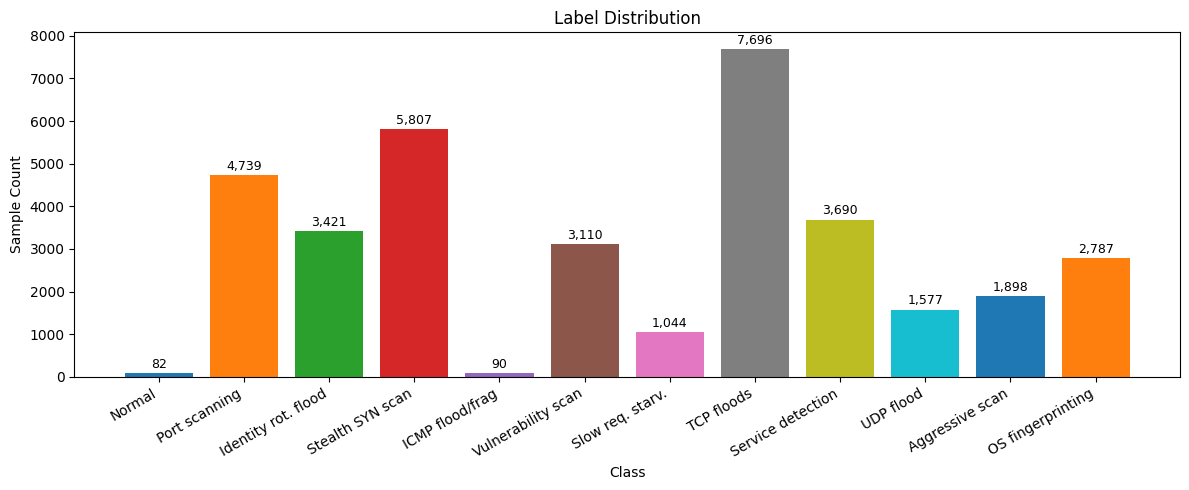

In [64]:
# Bar plot of label value counts with class names
label_names = {
    0: 'Normal',
    1: 'Port scanning',
    2: 'Identity rot. flood',
    3: 'Stealth SYN scan',
    4: 'ICMP flood/frag',
    5: 'Vulnerability scan',
    6: 'Slow req. starv.',
    7: 'TCP floods',
    8: 'Service detection',
    9: 'UDP flood',
    10: 'Aggressive scan',
    11: 'OS fingerprinting',
}

counts = df['Label'].value_counts().sort_index()
labels = [label_names[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, counts.values, color=sns.color_palette('tab10', len(counts)))
ax.set_xlabel('Class')
ax.set_ylabel('Sample Count')
ax.set_title('Label Distribution')
ax.set_xticklabels(labels, rotation=30, ha='right')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Data pre-processing

In [65]:
# Encode the dataset
labelencoder = LabelEncoder()
df.iloc[:, -1] = labelencoder.fit_transform(df.iloc[:, -1])


In [66]:
# min-max normalization
for column in df.columns[:-1]: # excluding the last column
    df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
    

In [67]:
# address empty values
if df.isnull().values.any() or np.isinf(df).values.any(): # if there is any empty or infinite values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace = True)

In [68]:
X = df.drop(['Label'],axis=1)
y = df.iloc[:, -1]

# 3-fold stratified cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

### Reference Models from Literature

| Paper | Link | Models |
|-------|------|--------|
| Tree-based Intelligent Intrusion Detection System in Internet of Vehicles | [arXiv:1910.08635](https://arxiv.org/pdf/1910.08635) | Random Forest, Decision Tree, Extra Tree, XGBoost |
| MTH-IDS: A Multitiered Hybrid Intrusion Detection System for Internet of Vehicles | [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9443234) | Multi-SVM, KNN |
|A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles| [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9838780) | VGG16, VGG19|
|Deep Learning Approach for Intelligent Intrusion Detection System| [IEEE Xplore](https://ieeexplore.ieee.org/abstract/document/8681044)| DNN, LR|
| | | LightGBM|


In [69]:
def _per_class_from_conf_matrix(conf_matrix, labels):
    """Derive per-class precision/recall/f1 from a summed confusion matrix."""
    per_class = {}
    for i, lbl in enumerate(labels):
        tp = conf_matrix[i, i]
        fp = conf_matrix[:, i].sum() - tp
        fn = conf_matrix[i, :].sum() - tp
        support = conf_matrix[i, :].sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        per_class[str(lbl)] = {"precision": prec, "recall": rec, "f1-score": f1, "support": float(support)}
    return per_class


def train_xgboost(
    X, y, cv,
    model_name: str = "XGBoost (default)",
    model_path: str = f"{MODEL_DIR}/xgboost.json",
    n_iter: int = 20,
) -> ModelResult:
    """Train XGBoost with RandomizedSearchCV + stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = xgb.XGBClassifier()
        model.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0
        best_params = None
        best_fold_acc = -1

        param_dist = {
            'n_estimators': [100, 200, 300, 500],
            'max_depth': [3, 5, 7, 9, 11],
            'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
            'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
            'min_child_weight': [1, 3, 5, 7],
            'gamma': [0, 0.1, 0.2, 0.3],
        }

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Running RandomizedSearchCV ({n_iter} iterations)...")
            search = RandomizedSearchCV(
                xgb.XGBClassifier(random_state=42), param_dist,
                n_iter=n_iter, cv=3,
                scoring='accuracy',
                n_jobs=-1,
                random_state=42,
                verbose=0,
            )

            start = time.time()
            search.fit(X_train, y_train)
            total_train_time += time.time() - start

            model = search.best_estimator_
            print(f"  Fold {fold_i}: Best params={search.best_params_}")

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            if fold_acc[-1] > best_fold_acc:
                best_fold_acc = fold_acc[-1]
                best_params = search.best_params_

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset with best params and save
        model = xgb.XGBClassifier(random_state=42, **best_params)
        model.fit(X, y)
        model.save_model(model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
            "best_params": best_params,
            "best_cv_score": float(np.mean(fold_acc)),
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name,
        training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)),
        precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)),
        f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)),
        precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)),
        f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


xgb_result = train_xgboost(X, y, cv, model_name="XGBoost (default)")
print(f"Done — {xgb_result.model_name}  |  Accuracy: {xgb_result.accuracy*100:.3f}% ± {xgb_result.accuracy_std*100:.3f}%")


Loading cached XGBoost (default) from models/xgboost.json
  Fold 1: Accuracy=100.000%
  Fold 2: Accuracy=100.000%
  Fold 3: Accuracy=100.000%
Done — XGBoost (default)  |  Accuracy: 100.000% ± 0.000%


In [70]:
def train_random_forest(
    X, y, cv,
    model_name: str = "Random Forest",
    model_path: str = f"{MODEL_DIR}/random_forest.pkl",
    n_iter: int = 20,
) -> ModelResult:
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0
        best_params = None
        best_fold_acc = -1

        param_dist = {
            'n_estimators': [100, 200, 300, 500, 700],
            'max_depth': [None, 5, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None],
            'bootstrap': [True, False],
        }

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Running RandomizedSearchCV ({n_iter} iterations)...")
            search = RandomizedSearchCV(
                RandomForestClassifier(random_state=42), param_dist,
                n_iter=n_iter, cv=3, scoring='accuracy',
                n_jobs=-1, random_state=42, verbose=0,
            )

            start = time.time()
            search.fit(X_train, y_train)
            total_train_time += time.time() - start

            model = search.best_estimator_
            print(f"  Fold {fold_i}: Best params={search.best_params_}")

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            if fold_acc[-1] > best_fold_acc:
                best_fold_acc = fold_acc[-1]
                best_params = search.best_params_

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset with best params and save
        model = RandomForestClassifier(random_state=42, **best_params)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
            "best_params": best_params,
            "best_cv_score": float(np.mean(fold_acc)),
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


rf_result = train_random_forest(X, y, cv, model_name="Random Forest")
print(f"Done — {rf_result.model_name}  |  Accuracy: {rf_result.accuracy*100:.3f}% ± {rf_result.accuracy_std*100:.3f}%")


Loading cached Random Forest from models/random_forest.pkl
  Fold 1: Accuracy=100.000%
  Fold 2: Accuracy=100.000%
  Fold 3: Accuracy=100.000%
Done — Random Forest  |  Accuracy: 100.000% ± 0.000%


In [71]:
def train_decision_tree(
    X, y, cv,
    model_name: str = "Decision Tree",
    model_path: str = f"{MODEL_DIR}/decision_tree.pkl",
    n_iter: int = 20,
) -> ModelResult:
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0
        best_params = None
        best_fold_acc = -1

        param_dist = {
            'max_depth': [None, 5, 10, 20, 30, 50],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 4, 8],
            'max_features': ['sqrt', 'log2', None],
            'criterion': ['gini', 'entropy'],
        }

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Running RandomizedSearchCV ({n_iter} iterations)...")
            search = RandomizedSearchCV(
                DecisionTreeClassifier(random_state=42), param_dist,
                n_iter=n_iter, cv=3, scoring='accuracy',
                n_jobs=-1, random_state=42, verbose=0,
            )

            start = time.time()
            search.fit(X_train, y_train)
            total_train_time += time.time() - start

            model = search.best_estimator_
            print(f"  Fold {fold_i}: Best params={search.best_params_}")

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            if fold_acc[-1] > best_fold_acc:
                best_fold_acc = fold_acc[-1]
                best_params = search.best_params_

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset with best params and save
        model = DecisionTreeClassifier(random_state=42, **best_params)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
            "best_params": best_params,
            "best_cv_score": float(np.mean(fold_acc)),
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


dt_result = train_decision_tree(X, y, cv, model_name="Decision Tree")
print(f"Done — {dt_result.model_name}  |  Accuracy: {dt_result.accuracy*100:.3f}% ± {dt_result.accuracy_std*100:.3f}%")


Loading cached Decision Tree from models/decision_tree.pkl
  Fold 1: Accuracy=100.000%
  Fold 2: Accuracy=99.992%
  Fold 3: Accuracy=99.975%
Done — Decision Tree  |  Accuracy: 99.989% ± 0.010%


In [72]:
def train_extra_trees(
    X, y, cv,
    model_name: str = "Extra Trees",
    model_path: str = f"{MODEL_DIR}/extra_trees.pkl",
    n_iter: int = 20,
) -> ModelResult:
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0
        best_params = None
        best_fold_acc = -1

        param_dist = {
            'n_estimators': [100, 200, 300, 500, 700],
            'max_depth': [None, 5, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None],
            'bootstrap': [True, False],
        }

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Running RandomizedSearchCV ({n_iter} iterations)...")
            search = RandomizedSearchCV(
                ExtraTreesClassifier(random_state=42), param_dist,
                n_iter=n_iter, cv=3, scoring='accuracy',
                n_jobs=-1, random_state=42, verbose=0,
            )

            start = time.time()
            search.fit(X_train, y_train)
            total_train_time += time.time() - start

            model = search.best_estimator_
            print(f"  Fold {fold_i}: Best params={search.best_params_}")

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            if fold_acc[-1] > best_fold_acc:
                best_fold_acc = fold_acc[-1]
                best_params = search.best_params_

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset with best params and save
        model = ExtraTreesClassifier(random_state=42, **best_params)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
            "best_params": best_params,
            "best_cv_score": float(np.mean(fold_acc)),
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


et_result = train_extra_trees(X, y, cv, model_name="Extra Trees")
print(f"Done — {et_result.model_name}  |  Accuracy: {et_result.accuracy*100:.3f}% ± {et_result.accuracy_std*100:.3f}%")


Loading cached Extra Trees from models/extra_trees.pkl
  Fold 1: Accuracy=100.000%
  Fold 2: Accuracy=100.000%
  Fold 3: Accuracy=100.000%
Done — Extra Trees  |  Accuracy: 100.000% ± 0.000%


In [73]:
def train_svm(
    X, y,
    model_name: str = "Multi-SVM",
    model_path: str = f"{MODEL_DIR}/svm.pkl",
    n_iter: int = 20,
    test_size: float = 0.2,
) -> ModelResult:
    registry = _load_registry()
    all_labels = sorted(np.unique(y))
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
    else:
        param_dist = {
            'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
            'C': [0.1, 0.5, 1, 5, 10, 50],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
            'degree': [2, 3, 4],
            'coef0': [0.0, 0.1, 0.5, 1.0],
        }

        print(f"  Running RandomizedSearchCV ({n_iter} iterations)...")
        search = RandomizedSearchCV(
            SVC(random_state=42), param_dist,
            n_iter=n_iter, cv=3, scoring='accuracy',
            n_jobs=-1, random_state=42, verbose=0,
        )

        start = time.time()
        search.fit(X_train, y_train)
        total_train_time = time.time() - start

        best_params = search.best_params_
        model = search.best_estimator_
        print(f"  Best params={best_params}")

        # Retrain on full dataset with best params and save
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
            "best_params": best_params,
            "best_cv_score": float(accuracy_score(y_test, model.predict(X_test))),
        }
        _save_registry(registry)

    start = time.time()
    y_pred = model.predict(X_test)
    total_infer_time = time.time() - start
    total_test_samples = len(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    fold_conf = confusion_matrix(y_test, y_pred, labels=all_labels)
    print(f"  Accuracy={acc*100:.3f}%")

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(acc), precision=float(prec),
        recall=float(rec), f1_score=float(f1),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


svm_result = train_svm(X, y, model_name="Multi-SVM")
print(f"Done — {svm_result.model_name}  |  Accuracy: {svm_result.accuracy*100:.3f}%")


Loading cached Multi-SVM from models/svm.pkl
  Accuracy=60.509%
Done — Multi-SVM  |  Accuracy: 60.509%


In [74]:
def train_knn(
    X, y, cv,
    model_name: str = "KNN",
    model_path: str = f"{MODEL_DIR}/knn.pkl",
    n_iter: int = 20,
) -> ModelResult:
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0
        best_params = None
        best_fold_acc = -1

        param_dist = {
            'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski'],
            'p': [1, 2, 3],
            'leaf_size': [20, 30, 40, 50],
        }

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Running RandomizedSearchCV ({n_iter} iterations)...")
            search = RandomizedSearchCV(
                KNeighborsClassifier(), param_dist,
                n_iter=n_iter, cv=3, scoring='accuracy',
                n_jobs=-1, random_state=42, verbose=0,
            )

            start = time.time()
            search.fit(X_train, y_train)
            total_train_time += time.time() - start

            model = search.best_estimator_
            print(f"  Fold {fold_i}: Best params={search.best_params_}")

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            if fold_acc[-1] > best_fold_acc:
                best_fold_acc = fold_acc[-1]
                best_params = search.best_params_

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset with best params and save
        model = KNeighborsClassifier(**best_params)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
            "best_params": best_params,
            "best_cv_score": float(np.mean(fold_acc)),
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


knn_result = train_knn(X, y, cv, model_name="KNN")
print(f"Done — {knn_result.model_name}  |  Accuracy: {knn_result.accuracy*100:.3f}% ± {knn_result.accuracy_std*100:.3f}%")


Loading cached KNN from models/knn.pkl
  Fold 1: Accuracy=100.000%
  Fold 2: Accuracy=100.000%
  Fold 3: Accuracy=100.000%
Done — KNN  |  Accuracy: 100.000% ± 0.000%


In [75]:
def train_logistic_regression(
    X, y, cv,
    model_name: str = "Logistic Regression",
    model_path: str = f"{MODEL_DIR}/logistic_regression.pkl",
    n_iter: int = 20,
) -> ModelResult:
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0
        best_params = None
        best_fold_acc = -1

        param_dist = {
            'C': [0.01, 0.1, 0.5, 1, 5, 10, 50],
            'solver': ['lbfgs', 'saga'],
            'penalty': ['l2'],
            'max_iter': [500, 1000, 2000],
        }

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Running RandomizedSearchCV ({n_iter} iterations)...")
            search = RandomizedSearchCV(
                LogisticRegression(random_state=42), param_dist,
                n_iter=n_iter, cv=3, scoring='accuracy',
                n_jobs=-1, random_state=42, verbose=0,
                error_score='raise',
            )

            start = time.time()
            search.fit(X_train, y_train)
            total_train_time += time.time() - start

            model = search.best_estimator_
            print(f"  Fold {fold_i}: Best params={search.best_params_}")

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            if fold_acc[-1] > best_fold_acc:
                best_fold_acc = fold_acc[-1]
                best_params = search.best_params_

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset with best params and save
        model = LogisticRegression(random_state=42, **best_params)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
            "best_params": best_params,
            "best_cv_score": float(np.mean(fold_acc)),
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


lr_result = train_logistic_regression(X, y, cv, model_name="Logistic Regression")
print(f"Done — {lr_result.model_name}  |  Accuracy: {lr_result.accuracy*100:.3f}% ± {lr_result.accuracy_std*100:.3f}%")


Loading cached Logistic Regression from models/logistic_regression.pkl
  Fold 1: Accuracy=60.204%
  Fold 2: Accuracy=60.601%
  Fold 3: Accuracy=60.200%
Done — Logistic Regression  |  Accuracy: 60.335% ± 0.188%


In [76]:
def train_dnn(
    X, y, cv,
    model_name: str = "DNN",
    model_path: str = f"{MODEL_DIR}/dnn.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """
    Deep Neural Network per the paper architecture:
    FC(1024)->BN->Drop -> FC(768)->BN->Drop -> FC(512)->BN->Drop
    -> FC(256)->BN->Drop -> FC(128)->BN->Drop -> FC(n_classes, softmax)
    """
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            probs = model.predict(X_test.values, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                inp = tf.keras.Input(shape=(n_features,))
                x = inp
                for units in [1024, 768, 512, 256, 128]:
                    x = layers.Dense(units, activation='relu')(x)
                    x = layers.BatchNormalization()(x)
                    x = layers.Dropout(0.01)(x)
                out = layers.Dense(n_classes, activation='softmax')(x)

                model = tf.keras.Model(inp, out)
                model.compile(optimizer='adam',
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_train.values, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_test.values, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        with tf_strategy.scope():
            inp = tf.keras.Input(shape=(n_features,))
            x = inp
            for units in [1024, 768, 512, 256, 128]:
                x = layers.Dense(units, activation='relu')(x)
                x = layers.BatchNormalization()(x)
                x = layers.Dropout(0.01)(x)
            out = layers.Dense(n_classes, activation='softmax')(x)
            model = tf.keras.Model(inp, out)
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        model.fit(X.values, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


dnn_result = train_dnn(X, y, cv)
print(f"Done — {dnn_result.model_name}  |  Accuracy: {dnn_result.accuracy*100:.3f}% ± {dnn_result.accuracy_std*100:.3f}%")


Loading cached DNN from models/dnn.keras
  Fold 1: Accuracy=56.381%
  Fold 2: Accuracy=56.210%
  Fold 3: Accuracy=56.068%
Done — DNN  |  Accuracy: 56.220% ± 0.128%


In [77]:
def train_vgg16_1d(
    X, y, cv,
    model_name: str = "VGG16 (1D-CNN)",
    model_path: str = f"{MODEL_DIR}/vgg16_1d.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """VGG16 adapted as a 1D-CNN for tabular input (features -> (features,1))."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    def vgg_block_1d(x, filters, n_convs):
        for _ in range(n_convs):
            x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
        return layers.MaxPooling1D(2)(x)

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = X_test.values.reshape(-1, n_features, 1)
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = X_train.values.reshape(-1, n_features, 1)
            X_te = X_test.values.reshape(-1, n_features, 1)

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                inp = tf.keras.Input(shape=(n_features, 1))
                x = vgg_block_1d(inp, 64,  2)
                x = vgg_block_1d(x,  128, 2)
                x = vgg_block_1d(x,  256, 3)
                x = vgg_block_1d(x,  512, 3)
                x = vgg_block_1d(x,  512, 3)
                x = layers.GlobalAveragePooling1D()(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                out = layers.Dense(n_classes, activation='softmax')(x)
                model = tf.keras.Model(inp, out)
                model.compile(optimizer='adam',
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = X.values.reshape(-1, n_features, 1)
        with tf_strategy.scope():
            inp = tf.keras.Input(shape=(n_features, 1))
            x = vgg_block_1d(inp, 64,  2)
            x = vgg_block_1d(x,  128, 2)
            x = vgg_block_1d(x,  256, 3)
            x = vgg_block_1d(x,  512, 3)
            x = vgg_block_1d(x,  512, 3)
            x = layers.GlobalAveragePooling1D()(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            out = layers.Dense(n_classes, activation='softmax')(x)
            model = tf.keras.Model(inp, out)
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


vgg16_result = train_vgg16_1d(X, y, cv)
print(f"Done — {vgg16_result.model_name}  |  Accuracy: {vgg16_result.accuracy*100:.3f}% ± {vgg16_result.accuracy_std*100:.3f}%")


Loading cached VGG16 (1D-CNN) from models/vgg16_1d.keras
  Fold 1: Accuracy=21.409%
  Fold 2: Accuracy=21.411%
  Fold 3: Accuracy=21.419%
Done — VGG16 (1D-CNN)  |  Accuracy: 21.413% ± 0.004%


In [78]:
def train_vgg19_1d(
    X, y, cv,
    model_name: str = "VGG19 (1D-CNN)",
    model_path: str = f"{MODEL_DIR}/vgg19_1d.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """VGG19 adapted as a 1D-CNN. Blocks 3/4/5 use 4 Conv1D layers (vs 3 in VGG16)."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    def vgg_block_1d(x, filters, n_convs):
        for _ in range(n_convs):
            x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
        return layers.MaxPooling1D(2)(x)

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = X_test.values.reshape(-1, n_features, 1)
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = X_train.values.reshape(-1, n_features, 1)
            X_te = X_test.values.reshape(-1, n_features, 1)

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                inp = tf.keras.Input(shape=(n_features, 1))
                x = vgg_block_1d(inp, 64,  2)
                x = vgg_block_1d(x,  128, 2)
                x = vgg_block_1d(x,  256, 4)   # VGG19: 4 convs
                x = vgg_block_1d(x,  512, 4)
                x = vgg_block_1d(x,  512, 4)
                x = layers.GlobalAveragePooling1D()(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                out = layers.Dense(n_classes, activation='softmax')(x)
                model = tf.keras.Model(inp, out)
                model.compile(optimizer='adam',
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = X.values.reshape(-1, n_features, 1)
        with tf_strategy.scope():
            inp = tf.keras.Input(shape=(n_features, 1))
            x = vgg_block_1d(inp, 64,  2)
            x = vgg_block_1d(x,  128, 2)
            x = vgg_block_1d(x,  256, 4)
            x = vgg_block_1d(x,  512, 4)
            x = vgg_block_1d(x,  512, 4)
            x = layers.GlobalAveragePooling1D()(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            out = layers.Dense(n_classes, activation='softmax')(x)
            model = tf.keras.Model(inp, out)
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


vgg19_result = train_vgg19_1d(X, y, cv)
print(f"Done — {vgg19_result.model_name}  |  Accuracy: {vgg19_result.accuracy*100:.3f}% ± {vgg19_result.accuracy_std*100:.3f}%")


Loading cached VGG19 (1D-CNN) from models/vgg19_1d.keras
  Fold 1: Accuracy=21.409%
  Fold 2: Accuracy=21.411%
  Fold 3: Accuracy=21.419%
Done — VGG19 (1D-CNN)  |  Accuracy: 21.413% ± 0.004%


In [79]:
def train_cnn(
    X, y, cv,
    model_name: str = "CNN",
    model_path: str = f"{MODEL_DIR}/cnn.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """
    1-D CNN for tabular input (features -> (features, 1)).
    Architecture from CICEVSE2024 DL example:
      Conv1D(64,5)+BN -> Conv1D(64,3)+BN -> MaxPool -> Drop
      Conv1D(128,5)+BN -> Conv1D(128,3)+BN -> MaxPool -> Drop
      Conv1D(256,3)+BN -> Conv1D(256,3)+BN -> GlobalMaxPool
      Dense(256)+BN+Drop -> Dense(128)+Drop -> Dense(n_classes, softmax)
    """
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    def _build_cnn(n_features, n_classes):
        inp = tf.keras.Input(shape=(n_features, 1))
        # Block 1
        x = layers.Conv1D(64, 5, padding='same', activation='relu')(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Dropout(0.15)(x)
        # Block 2
        x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Dropout(0.20)(x)
        # Block 3
        x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.20)(x)
        x = layers.GlobalMaxPooling1D()(x)
        # Dense head
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.25)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.15)(x)
        out = layers.Dense(n_classes, activation='softmax')(x)
        model = tf.keras.Model(inp, out)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )
        return model

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = X_test.values.reshape(-1, n_features, 1)
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = X_train.values.reshape(-1, n_features, 1)
            X_te = X_test.values.reshape(-1, n_features, 1)

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                model = _build_cnn(n_features, n_classes)

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = X.values.reshape(-1, n_features, 1)
        with tf_strategy.scope():
            model = _build_cnn(n_features, n_classes)
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


cnn_result = train_cnn(X, y, cv)
print(f"Done — {cnn_result.model_name}  |  Accuracy: {cnn_result.accuracy*100:.3f}% ± {cnn_result.accuracy_std*100:.3f}%")

Loading cached CNN from models/cnn.keras
  Fold 1: Accuracy=69.402%
  Fold 2: Accuracy=69.132%
  Fold 3: Accuracy=68.881%
Done — CNN  |  Accuracy: 69.138% ± 0.212%


In [80]:
def train_lstm(
    X, y, cv,
    model_name: str = "LSTM",
    model_path: str = f"{MODEL_DIR}/lstm.keras",
    epochs: int = 60,
    batch_size: int = 256,
    chunk_size: int = 5,
) -> ModelResult:
    """
    LSTM for tabular input using chunked feature sequences.
    Features are grouped into chunks of `chunk_size` to form a sequence,
    then processed by: Dense(32) projection -> LSTM(64) -> Dense(64) -> Dense(n_classes).
    """
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    # Compute padding so n_features is divisible by chunk_size
    remainder = n_features % chunk_size
    pad_width = 0 if remainder == 0 else (chunk_size - remainder)
    timesteps = (n_features + pad_width) // chunk_size

    def _reshape_for_lstm(arr):
        if pad_width > 0:
            arr = np.concatenate([arr, np.zeros((arr.shape[0], pad_width), dtype=np.float32)], axis=1)
        return arr.reshape((arr.shape[0], timesteps, chunk_size))

    def _build_lstm(timesteps, step_features, n_classes):
        inp = tf.keras.Input(shape=(timesteps, step_features))
        x = layers.Dense(32, activation='relu')(inp)
        x = layers.Dropout(0.10)(x)
        x = layers.LSTM(64)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.15)(x)
        out = layers.Dense(n_classes, activation='softmax')(x)
        model = tf.keras.Model(inp, out)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )
        return model

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = _reshape_for_lstm(X_test.values.astype(np.float32))
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = _reshape_for_lstm(X_train.values.astype(np.float32))
            X_te = _reshape_for_lstm(X_test.values.astype(np.float32))

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                model = _build_lstm(timesteps, chunk_size, n_classes)

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = _reshape_for_lstm(X.values.astype(np.float32))
        with tf_strategy.scope():
            model = _build_lstm(timesteps, chunk_size, n_classes)
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


lstm_result = train_lstm(X, y, cv)
print(f"Done — {lstm_result.model_name}  |  Accuracy: {lstm_result.accuracy*100:.3f}% ± {lstm_result.accuracy_std*100:.3f}%")

Loading cached LSTM from models/lstm.keras
  Fold 1: Accuracy=60.813%
  Fold 2: Accuracy=60.935%
  Fold 3: Accuracy=60.609%
Done — LSTM  |  Accuracy: 60.786% ± 0.134%


In [81]:
def train_lightgbm(
    X, y,
    model_name: str = "LightGBM",
    model_path: str = f"{MODEL_DIR}/lightgbm.pkl",
    test_size: float = 0.2,
) -> ModelResult:
    """Train LightGBM with default parameters (no hyperparameter search)."""
    registry = _load_registry()
    all_labels = sorted(np.unique(y))
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
    else:
        model = lgb.LGBMClassifier(random_state=42, verbose=-1)

        start = time.time()
        model.fit(X_train, y_train)
        total_train_time = time.time() - start

        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    start = time.time()
    y_pred = model.predict(X_test)
    total_infer_time = time.time() - start
    total_test_samples = len(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    fold_conf = confusion_matrix(y_test, y_pred, labels=all_labels)
    print(f"  Accuracy={acc*100:.3f}%")

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(acc), precision=float(prec),
        recall=float(rec), f1_score=float(f1),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


lgb_result = train_lightgbm(X, y)
print(f"Done — {lgb_result.model_name}  |  Accuracy: {lgb_result.accuracy*100:.3f}%")

  Accuracy=99.833%
Done — LightGBM  |  Accuracy: 99.833%


In [91]:
# Accumulate all ModelResult objects — add/remove entries here as needed
results: List[ModelResult] = [
    xgb_result,
    rf_result,
    dt_result,
    et_result,
    svm_result,
    knn_result,
    lr_result,
    dnn_result,
    vgg16_result,
    vgg19_result,
    cnn_result,
    lstm_result,
    lgb_result,
]

summary_df = pd.DataFrame([r.to_summary_dict() for r in results]).set_index('Model')
display(summary_df.style
    .format(precision=4)
    .highlight_max(subset=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)' ], color='darkgreen')
    .highlight_min(subset=['Train Time (s)', 'Infer. Time (ms/sample)'], color='darkblue')
    .set_caption("3-Fold Stratified CV — Model Comparison Summary")
)


,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Train Time (s),Infer. Time (ms/sample)
Model,,,,,,
XGBoost (default),100.000 ± 0.000,100.000 ± 0.000,100.000 ± 0.000,100.000 ± 0.000,324.1640,0.0063
Random Forest,100.000 ± 0.000,100.000 ± 0.000,100.000 ± 0.000,100.000 ± 0.000,570.0880,0.0279
Decision Tree,99.989 ± 0.010,99.989 ± 0.010,99.989 ± 0.010,99.989 ± 0.010,2.5760,0.0003
Extra Trees,100.000 ± 0.000,100.000 ± 0.000,100.000 ± 0.000,100.000 ± 0.000,214.4640,0.0594
Multi-SVM,60.509 ± 0.000,59.701 ± 0.000,60.509 ± 0.000,54.517 ± 0.000,792.7450,1.2856
KNN,100.000 ± 0.000,100.000 ± 0.000,100.000 ± 0.000,100.000 ± 0.000,882.3750,0.7565
Logistic Regression,60.335 ± 0.188,59.816 ± 2.081,60.335 ± 0.188,54.656 ± 0.186,833.2880,0.0011
DNN,56.220 ± 0.128,57.806 ± 0.756,56.220 ± 0.128,52.320 ± 0.137,156.2270,0.0668
VGG16 (1D-CNN),21.413 ± 0.004,4.585 ± 0.002,21.413 ± 0.004,7.553 ± 0.003,610.8420,0.1270


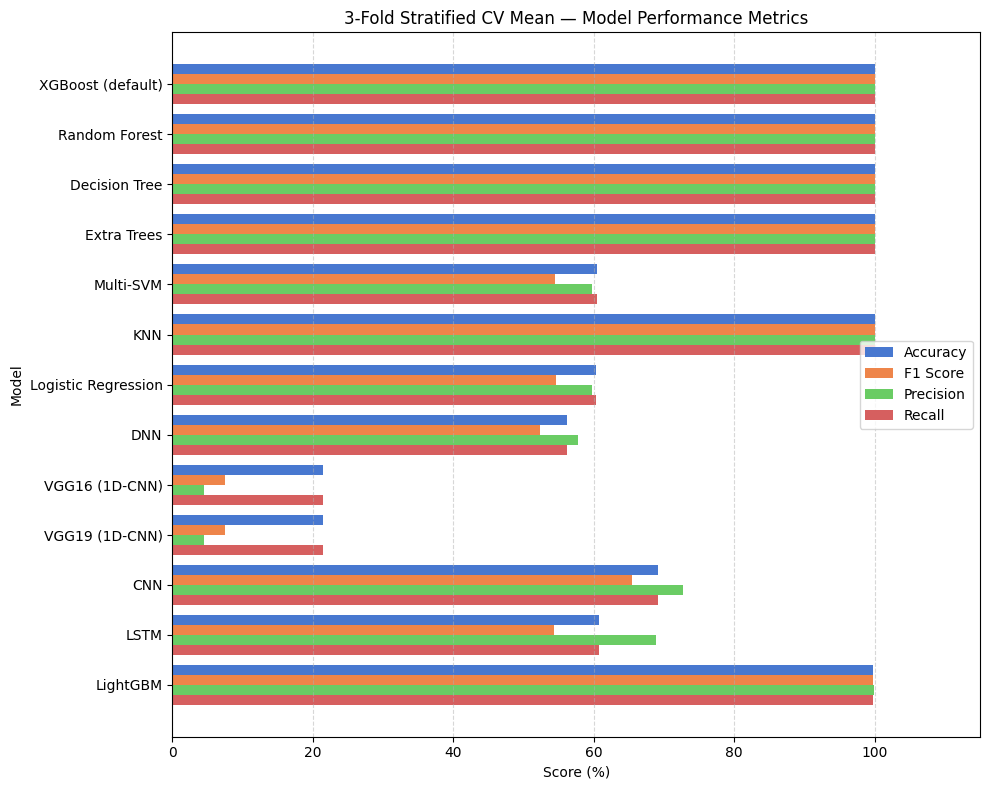

In [83]:
names     = [r.model_name for r in results]
acc       = [r.accuracy   * 100 for r in results]
f1        = [r.f1_score   * 100 for r in results]
precision = [r.precision  * 100 for r in results]
recall    = [r.recall     * 100 for r in results]

metrics      = [acc, f1, precision, recall]
metric_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
colors       = sns.color_palette('muted', 4)

y      = np.arange(len(names))
height = 0.2

fig, ax = plt.subplots(figsize=(10, 8))
for i, (vals, label, color) in enumerate(zip(metrics, metric_names, colors)):
    ax.barh(y + i * height, vals, height, label=label, color=color)

ax.set_ylabel('Model')
ax.set_xlabel('Score (%)')
ax.set_title('3-Fold Stratified CV Mean — Model Performance Metrics')
ax.set_yticks(y + height * (len(metrics) - 1) / 2)
ax.set_yticklabels(names)
ax.set_xlim(0, 115)
ax.invert_yaxis()
ax.legend()
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


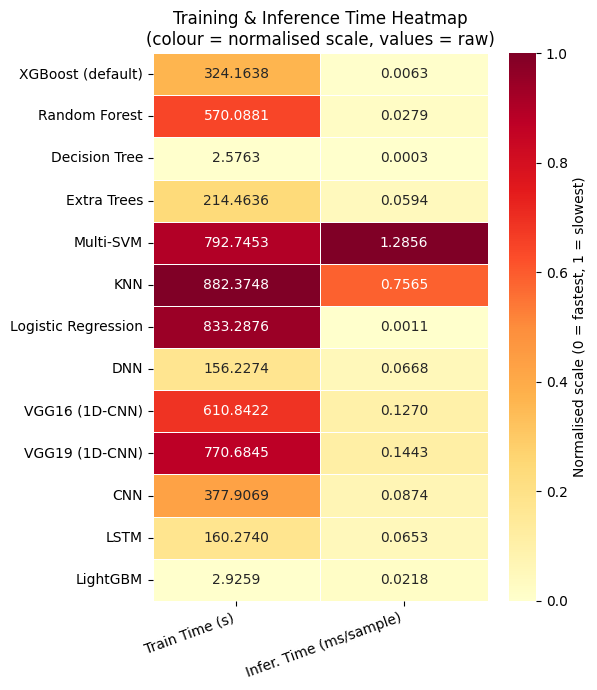

In [84]:
# Heatmap: Training time & Inference time
time_df = pd.DataFrame({
    "Train Time (s)":         [r.training_time_s   for r in results],
    "Infer. Time (ms/sample)":[r.inference_time_ms for r in results],
}, index=names)

# Min-max normalise each column for colour scale
norm_df = (time_df - time_df.min()) / (time_df.max() - time_df.min())

# Annotation strings showing raw values
annot = time_df.map(lambda v: f"{v:.4f}")

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(
    norm_df, annot=annot, fmt='', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Normalised scale (0 = fastest, 1 = slowest)'}
)
ax.set_title("Training & Inference Time Heatmap\n(colour = normalised scale, values = raw)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()